# TruFor S2 — Confusion Matrix · ROC (mvtb 200 + csvted 200)

GPU 없이 **로컬 PC**에서 시각화합니다.

## 준비

1. `pip install matplotlib seaborn scikit-learn numpy pandas`
2. **predictions.json 2개**를 GPU에서 받아 `data/trufor-s2/`에 둡니다.
3. Kernel Restart 후 **Run All**.

| 벤치 | 로컬 파일 |
|------|-----------|
| mvtb 200 | `data/trufor-s2/predictions_mvtb200.json` |
| csvted 200 | `data/trufor-s2/predictions_csvted200.json` |

**CM 표기:** Positive = fake (팀 GMFlow/Xception 노트북과 동일)

```powershell
$DATA = "c:\FINAL\ai-forensic\docs\notebooks\data\trufor-s2"
New-Item -ItemType Directory -Force -Path $DATA | Out-Null
scp sk4team@58.127.241.84:~/forenShield-ai/forgery/results/infer/trufor-mvtb200-forgery-s2-20260703-1419-20260703-1419/predictions.json "$DATA\predictions_mvtb200.json"
scp sk4team@58.127.241.84:~/forenShield-ai/forgery/results/infer/trufor-csvted200-forgery-s2-20260703-1419-20260703-1419/predictions.json "$DATA\predictions_csvted200.json"
```

In [14]:
# %pip install matplotlib seaborn scikit-learn numpy pandas

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve


def _setup_korean_font() -> str:
    candidates = [
        "Malgun Gothic", "NanumGothic", "Nanum Gothic",
        "AppleGothic", "Noto Sans CJK KR", "Noto Sans KR",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    mpl.rcParams["axes.unicode_minus"] = False
    return "default"


print(f"matplotlib font: {_setup_korean_font()}")

# notebooks/output 에서 실행 시 ../data, ./output/trufor-s2-cm
CWD = Path.cwd().resolve()
if (CWD / "data").is_dir():
    NOTEBOOK_ROOT = CWD
elif (CWD.parent / "data").is_dir():
    NOTEBOOK_ROOT = CWD.parent
else:
    NOTEBOOK_ROOT = Path(r"c:\FINAL\ai-forensic\docs\notebooks")

DATA_DIR = NOTEBOOK_ROOT / "data" / "trufor-s2"
OUT_DIR = NOTEBOOK_ROOT / "output" / "trufor-s2-cm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = DATA_DIR / "trufor_s2_benchmark_summary.json"
PRED_FILES = {
    "mvtb200": DATA_DIR / "predictions_mvtb200.json",
    "csvted200": DATA_DIR / "predictions_csvted200.json",
}

LABELS_TEAM = ["fake", "real"]
MODEL_LABEL = "TruFor S2 (forgery-s2-20260703-1419)"
THRESHOLDS = {
    "mvtb200": 0.5,
    "csvted200": 0.5,
}

summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUT_DIR:  {OUT_DIR}")
print(f"run:      {summary['run_name']}")

matplotlib font: Malgun Gothic
DATA_DIR: C:\FINAL\ai-forensic\docs\notebooks\data\trufor-s2
OUT_DIR:  C:\FINAL\ai-forensic\docs\notebooks\output\trufor-s2-cm
run:      forgery-s2-20260703-1419


In [15]:
def load_predictions(path: Path) -> list[dict]:
    data = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(data, dict) and "items" in data:
        return data["items"]
    if isinstance(data, list):
        return data
    raise ValueError(f"unexpected format: {path}")


def items_to_arrays(items: list[dict]) -> tuple[np.ndarray, np.ndarray]:
    labels, scores = [], []
    for x in items:
        g = x.get("ground_truth_label")
        y = 1 if g in ("fake", 1, "1", True) else 0
        labels.append(y)
        scores.append(float(x["tamper_score"]))
    return np.array(labels, dtype=np.int64), np.array(scores, dtype=np.float64)


def predict_at_threshold(scores: np.ndarray, thr: float) -> np.ndarray:
    return (scores >= thr).astype(np.int64)


def labels_to_team(y_bin: np.ndarray) -> list[str]:
    return ["fake" if y == 1 else "real" for y in y_bin]


def cm_from_confusion(c: dict) -> np.ndarray:
    # rows=fake, cols=[pred fake, pred real]
    return np.array([[c["tp"], c["fn"]], [c["fp"], c["tn"]]], dtype=int)


datasets: dict[str, dict] = {}
for name, path in PRED_FILES.items():
    entry = {"name": name, "path": path, "has_scores": path.is_file()}
    if path.is_file():
        items = load_predictions(path)
        y, s = items_to_arrays(items)
        entry.update({"items": items, "y": y, "scores": s, "n": len(items)})
        print(f"{name}: loaded n={len(items)} from {path.name}")
    else:
        bench = summary["benchmarks"][name]
        c = bench["confusion"]
        entry["cm_fallback"] = cm_from_confusion(c)
        entry["auc_fallback"] = bench.get("roc_auc")
        print(f"{name}: MISSING {path.name} — CM only from summary JSON")
    datasets[name] = entry

mvtb200: MISSING predictions_mvtb200.json — CM only from summary JSON
csvted200: MISSING predictions_csvted200.json — CM only from summary JSON


In [16]:
def plot_team_cm(cm: np.ndarray, title: str, out_path: Path | None = None):
    tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    annot = np.array([[f"{tp}\nTP", f"{fn}\nFN"], [f"{fp}\nFP", f"{tn}\nTN"]])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred 가짜 (Pos)", "Pred 진짜 (Neg)"],
        yticklabels=["Actual 가짜 (Pos)", "Actual 진짜 (Neg)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return cm


def plot_roc(y: np.ndarray, scores: np.ndarray, title: str, thr: float, out_path: Path | None = None):
    fpr, tpr, thresholds = roc_curve(y, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    # operating point @thr
    pred = predict_at_threshold(scores, thr)
    tp = int(((y == 1) & (pred == 1)).sum())
    fp = int(((y == 0) & (pred == 1)).sum())
    fn = int(((y == 1) & (pred == 0)).sum())
    tn = int(((y == 0) & (pred == 0)).sum())
    tpr_pt = tp / max(tp + fn, 1)
    fpr_pt = fp / max(fp + tn, 1)
    ax.scatter([fpr_pt], [tpr_pt], s=80, c="crimson", zorder=5, label=f"thr={thr} (TPR={tpr_pt:.2f}, FPR={fpr_pt:.2f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return roc_auc

MVTamperBench 200 @ thr=0.5
saved C:\FINAL\ai-forensic\docs\notebooks\output\trufor-s2-cm\cm_s2_mvtb200_summary.png


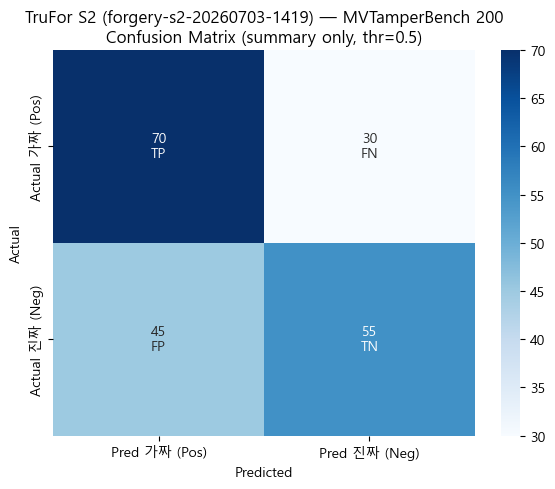

ROC skipped — scp predictions.json to enable full ROC curve.
CSV-TED 200 @ thr=0.5
saved C:\FINAL\ai-forensic\docs\notebooks\output\trufor-s2-cm\cm_s2_csvted200_summary.png


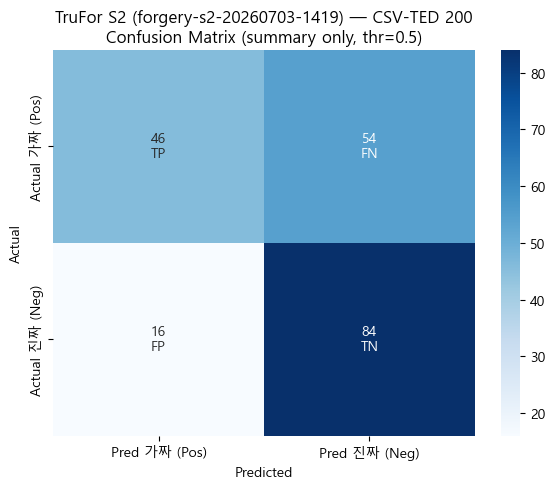

ROC skipped — scp predictions.json to enable full ROC curve.


In [17]:
for bench_key, label in [("mvtb200", "MVTamperBench 200"), ("csvted200", "CSV-TED 200")]:
    d = datasets[bench_key]
    thr = THRESHOLDS[bench_key]
    print("=" * 60)
    print(label, f"@ thr={thr}")

    if d.get("has_scores"):
        y_pred_bin = predict_at_threshold(d["scores"], thr)
        y_true_team = labels_to_team(d["y"])
        y_pred_team = labels_to_team(y_pred_bin)
        cm = confusion_matrix(y_true_team, y_pred_team, labels=LABELS_TEAM)
        plot_team_cm(
            cm,
            f"{MODEL_LABEL} — {label}\nConfusion Matrix (thr={thr})",
            OUT_DIR / f"cm_s2_{bench_key}.png",
        )
        print(classification_report(y_true_team, y_pred_team, labels=LABELS_TEAM, digits=3))
        plot_roc(
            d["y"], d["scores"],
            f"{MODEL_LABEL} — {label}\nROC Curve",
            thr,
            OUT_DIR / f"roc_s2_{bench_key}.png",
        )
    else:
        plot_team_cm(
            d["cm_fallback"],
            f"{MODEL_LABEL} — {label}\nConfusion Matrix (summary only, thr={thr})",
            OUT_DIR / f"cm_s2_{bench_key}_summary.png",
        )
        print("ROC skipped — scp predictions.json to enable full ROC curve.")

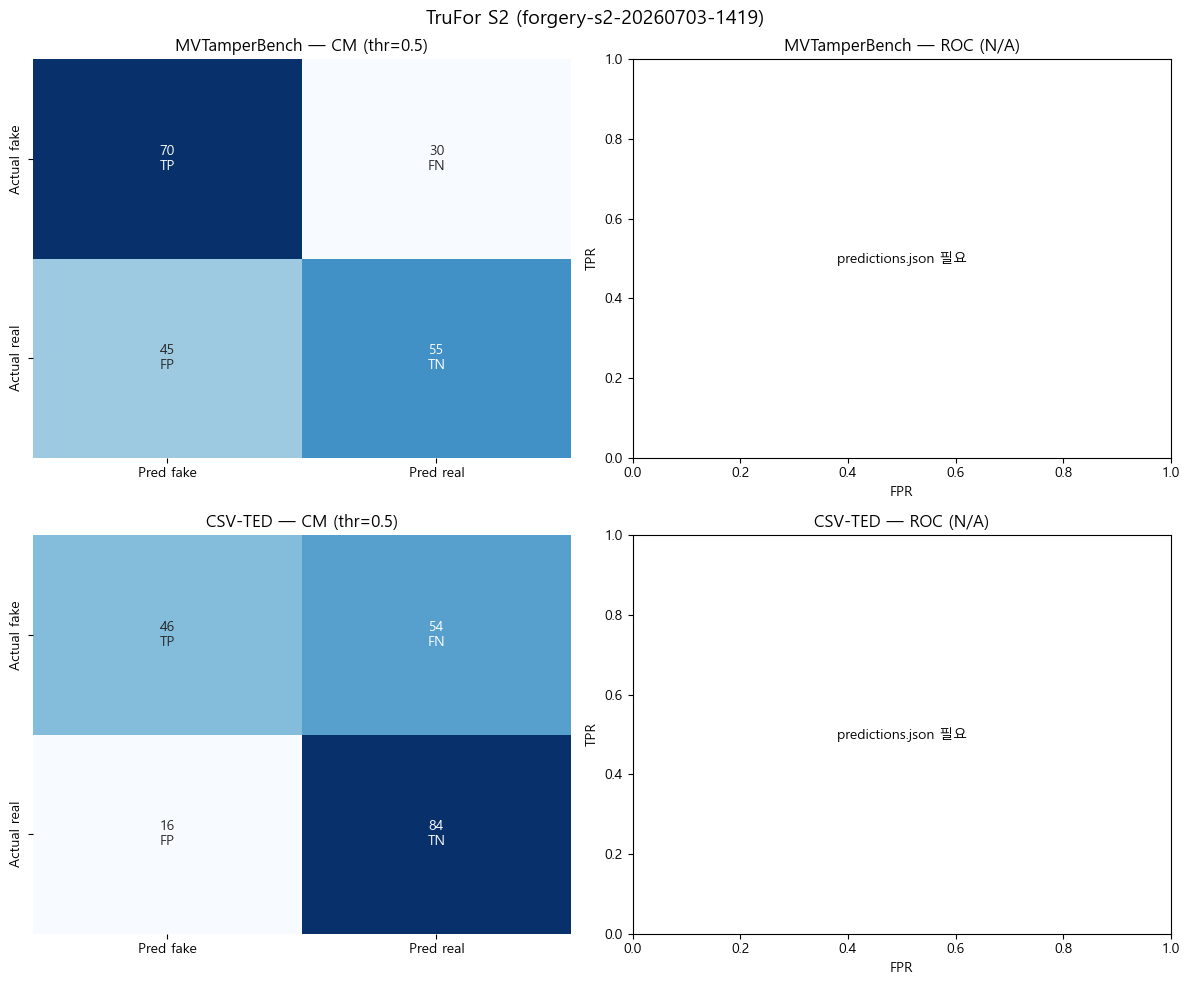

saved C:\FINAL\ai-forensic\docs\notebooks\output\trufor-s2-cm\trufor_s2_mvtb_csvted_cm_roc.png


In [18]:
# 벤치별 2x2: CM + ROC (scores 있을 때만)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
bench_order = [("mvtb200", "MVTamperBench"), ("csvted200", "CSV-TED")]

for row, (key, title) in enumerate(bench_order):
    d = datasets[key]
    thr = THRESHOLDS[key]
    ax_cm, ax_roc = axes[row]

    if d.get("has_scores"):
        y_pred_bin = predict_at_threshold(d["scores"], thr)
        cm = confusion_matrix(labels_to_team(d["y"]), labels_to_team(y_pred_bin), labels=LABELS_TEAM)
        fpr, tpr, _ = roc_curve(d["y"], d["scores"], pos_label=1)
        roc_auc = auc(fpr, tpr)
    else:
        cm = d["cm_fallback"]
        fpr, tpr, roc_auc = None, None, d.get("auc_fallback", float("nan"))

    annot = np.array([[f"{cm[0,0]}\nTP", f"{cm[0,1]}\nFN"], [f"{cm[1,0]}\nFP", f"{cm[1,1]}\nTN"]])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False, ax=ax_cm,
                xticklabels=["Pred fake", "Pred real"], yticklabels=["Actual fake", "Actual real"])
    ax_cm.set_title(f"{title} — CM (thr={thr})")

    if fpr is not None:
        ax_roc.plot(fpr, tpr, lw=2, label=f"AUC={roc_auc:.3f}")
        ax_roc.plot([0, 1], [0, 1], "--", color="gray")
        ax_roc.set_title(f"{title} — ROC")
        ax_roc.legend(loc="lower right")
    else:
        ax_roc.text(0.5, 0.5, "predictions.json 필요", ha="center", va="center")
        ax_roc.set_title(f"{title} — ROC (N/A)")
    ax_roc.set_xlabel("FPR")
    ax_roc.set_ylabel("TPR")

fig.suptitle(MODEL_LABEL, fontsize=14)
fig.tight_layout()
combo_path = OUT_DIR / "trufor_s2_mvtb_csvted_cm_roc.png"
fig.savefig(combo_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {combo_path}")

In [19]:
# S2 vs baseline vs R5 (mvtb) 요약표
rows = []
for bench in ("mvtb200", "csvted200"):
    s2 = summary["benchmarks"][bench]["confusion"]
    bl = summary["baseline_reference"][bench]["confusion"]
    rows.append({
        "bench": bench,
        "model": "S2",
        "thr": summary["benchmarks"][bench].get("threshold_infer", 0.5),
        "TP": s2["tp"], "FP": s2["fp"], "FN": s2["fn"], "TN": s2["tn"],
        "Acc": summary["benchmarks"][bench]["accuracy"],
        "AUC": summary["benchmarks"][bench].get("roc_auc"),
    })
    rows.append({
        "bench": bench,
        "model": "baseline",
        "thr": summary["baseline_reference"][bench]["threshold"],
        "TP": bl["tp"], "FP": bl["fp"], "FN": bl["fn"], "TN": bl["tn"],
        "Acc": summary["baseline_reference"][bench]["accuracy"],
        "AUC": summary["baseline_reference"][bench].get("roc_auc"),
    })

r5 = summary.get("r5_dev_reference", {}).get("mvtb200")
if r5:
    c = r5["confusion"]
    rows.append({
        "bench": "mvtb200", "model": "R5 dev", "thr": r5["threshold"],
        "TP": c["tp"], "FP": c["fp"], "FN": c["fn"], "TN": c["tn"],
        "Acc": r5["accuracy"], "AUC": None,
    })

df = pd.DataFrame(rows)
display(df)
df.to_csv(OUT_DIR / "trufor_s2_metrics_table.csv", index=False)
print(f"saved {OUT_DIR / 'trufor_s2_metrics_table.csv'}")

,bench,model,thr,TP,FP,FN,TN,Acc,AUC
0,mvtb200,S2,0.500,70,45,30,55,0.625,0.68955
1,mvtb200,baseline,0.500,63,51,37,49,0.560,0.57090
2,csvted200,S2,0.500,46,16,54,84,0.650,0.71200
3,csvted200,baseline,0.500,24,11,76,89,0.565,0.62850
4,mvtb200,R5 dev,0.185,96,19,4,81,0.885,NaN


saved C:\FINAL\ai-forensic\docs\notebooks\output\trufor-s2-cm\trufor_s2_metrics_table.csv
